# Microwave and radar tomography: inverse scattering

Point antennas at a hidden region, illuminate it with microwaves, and record the scattered field. From those
recordings, reconstruct what is inside -- a map of the material's electrical properties -- without ever
touching it. That is microwave tomography, and it is the imaging principle behind through-wall radar,
ground-penetrating radar, non-destructive testing of materials, airport security screening, and biomedical
microwave imaging (the experimental detection of breast tumours, strokes, and lung fluid). It is also one of
the hardest imaging problems there is, because the wave does not pass cleanly through the scene: it bends,
diffracts, and bounces between objects, so the map from the medium to the data is the full, nonlinear wave
equation.

This notebook works through that subject:

1. What microwave tomography is, and where it is used.
2. The electromagnetics -- Maxwell's equations reduced to the Helmholtz equation, permittivity, and contrast.
3. Scattering theory -- incident, scattered and total fields; the Born approximation and when it fails.
4. The forward model -- a frequency-domain Helmholtz solve with absorbing boundaries; a wavefield you can see.
5. Why it is hard -- ill-posedness, the diffraction limit, and how the data fill spatial-frequency space.
6. The classical imaging methods -- backpropagation, diffraction tomography, and the iterative Born/contrast-source family.
7. Bayesian full-wave inversion on mixle -- a contrast field, a complex Helmholtz forward, and a posterior.
8. Reconstruction and uncertainty, and how frequency diversity and view coverage change both.
9. Lossy targets -- recovering conductivity as well as permittivity.
10. A worked application -- a tissue-mimicking phantom imaged and its regions identified by permittivity.
11. Best practices -- priors, positivity, the inverse-crime trap, calibration, and model error.

The forward physics is the scalar Helmholtz equation; the inversions are posed on mixle's PDE-inverse
stack, so each reconstruction comes with a calibrated, per-voxel uncertainty. The scenes are synthetic but
built from realistic material properties; they are illustrative, with frequencies and sizes chosen to keep
the wave solves fast in a notebook.

## 1. What microwave tomography is

A tomography problem reconstructs the interior of a region from measurements made around its edge. In
X-ray CT the measurements are straight-line attenuation integrals and the reconstruction is a clean linear
inversion (the Radon transform). Microwaves are different: at the wavelengths used (centimetres to tens of
centimetres, roughly 0.3-10 GHz) the radiation diffracts around features comparable to a wavelength, so
energy does not travel in straight rays and there is no simple projection to invert. Instead, each
transmitter launches a wave that fills the whole scene, scatters off every contrast in material properties,
and is recorded by an array of receivers. The data are complex (amplitude and phase) scattered fields for
many transmitter-receiver pairs.

What makes microwaves worth the trouble is contrast. The quantity they sense -- the electrical permittivity
-- varies enormously between materials: a factor of fifty between dry and water-bearing media. That is why
microwave imaging can tell wet from dry, metal from plastic, fat from tumour, where an X-ray (sensitive to
density and atomic number) sometimes cannot. The price is the physics: the reconstruction must undo full-
wave, multiple scattering, which is nonlinear and ill-posed. The whole notebook is about paying that price
well.

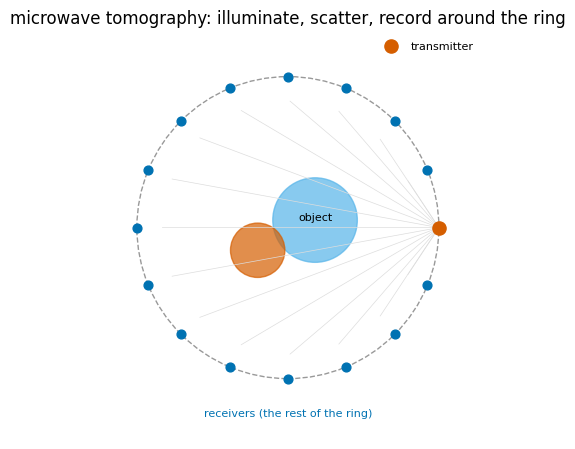

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# a schematic: a hidden region, a ring of antennas, one transmitter lighting up the scene
fig, ax = plt.subplots(figsize=(5.2, 4.6))
th = np.linspace(0, 2 * np.pi, 16, endpoint=False)
ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, ls='--', color='#999'))
ax.scatter(np.cos(th), np.sin(th), c='#0072B2', s=40, zorder=3)
ax.scatter([np.cos(th[0])], [np.sin(th[0])], c='#D55E00', s=90, zorder=4, label='transmitter')
ax.add_patch(plt.Circle((0.18, 0.05), 0.28, color='#56B4E9', alpha=0.7))
ax.add_patch(plt.Circle((-0.2, -0.15), 0.18, color='#D55E00', alpha=0.7))
for a in th[1:]:
    ax.annotate('', xy=(0.85 * np.cos(a), 0.85 * np.sin(a)), xytext=(np.cos(th[0]), np.sin(th[0])),
                arrowprops=dict(arrowstyle='-', color='#ddd', lw=0.5))
ax.text(0.18, 0.05, 'object', ha='center', fontsize=8); ax.text(0, -1.25, 'receivers (the rest of the ring)', ha='center', fontsize=8, color='#0072B2')
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.4, 1.3); ax.set_aspect('equal'); ax.axis('off')
ax.legend(loc='upper right', fontsize=8, frameon=False); ax.set_title('microwave tomography: illuminate, scatter, record around the ring')
plt.tight_layout(); plt.show()

## 2. From Maxwell to Helmholtz

Microwaves are electromagnetic waves governed by Maxwell's equations. For a non-magnetic medium and a single
temporal frequency $\omega$ (we work one frequency at a time, the time-harmonic convention $e^{-i\omega t}$),
the electric field reduces to a scalar Helmholtz equation in 2-D,
$$ \nabla^2 u + k_0^2\,\varepsilon_r(\mathbf{x})\,u = -\,s(\mathbf{x}), $$
where $k_0 = \omega/c = 2\pi/\lambda$ is the free-space wavenumber, $s$ the source, and
$\varepsilon_r(\mathbf{x})$ the complex relative permittivity. Its real part stores energy (how much the
material slows and bends the wave); its imaginary part, tied to conductivity $\sigma$ by
$\varepsilon_r = \varepsilon' + i\,\sigma/(\omega\varepsilon_0)$, absorbs it (loss). We write the medium as a
background plus a contrast,
$$ \varepsilon_r(\mathbf{x}) = \varepsilon_b\,\big(1 + \chi(\mathbf{x})\big), $$
so $\chi$ is zero in the background and non-zero exactly where there is something to image. The contrast is
the unknown. The table below lists permittivities of common materials at microwave frequencies: the huge
spread -- air near 1, plastics a few, biological tissue tens, water near eighty -- is the leverage microwave
imaging exploits.

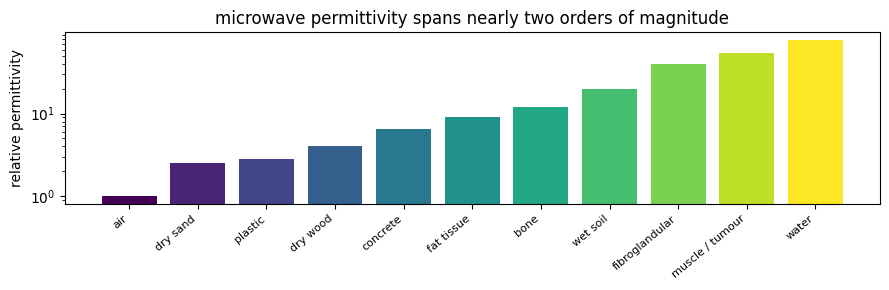

a wave slows by sqrt(eps_r): water (eps~78) carries a ~8.8x shorter wavelength than air


In [2]:
materials = {'air': 1.0, 'dry sand': 2.5, 'plastic': 2.8, 'dry wood': 4.0, 'concrete': 6.5,
             'fat tissue': 9.0, 'bone': 12.0, 'wet soil': 20.0, 'fibroglandular': 40.0,
             'muscle / tumour': 55.0, 'water': 78.0}
fig, ax = plt.subplots(figsize=(9, 3.0))
names = list(materials); vals = [materials[n] for n in names]
ax.bar(range(len(names)), vals, color=plt.cm.viridis(np.linspace(0, 1, len(names))))
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('relative permittivity'); ax.set_yscale('log'); ax.set_title('microwave permittivity spans nearly two orders of magnitude')
plt.tight_layout(); plt.show()
print('a wave slows by sqrt(eps_r): water (eps~78) carries a ~8.8x shorter wavelength than air')

## 3. Scattering theory and the Born approximation

Split the field into the incident field $u^{\mathrm{inc}}$ (what the source produces in the empty
background) and the scattered field $u^{\mathrm{sc}} = u - u^{\mathrm{inc}}$ (the part caused by the
contrast). The scattered field obeys the Lippmann-Schwinger integral equation
$$ u^{\mathrm{sc}}(\mathbf{x}) = k_0^2 \int G(\mathbf{x},\mathbf{x}')\,\varepsilon_b\,\chi(\mathbf{x}')\,
u(\mathbf{x}')\,d\mathbf{x}', $$
with $G$ the background Green's function. The catch is that the total field $u$ on the right depends on
$\chi$ -- the scattered field re-scatters. The Born approximation replaces $u$ by the known incident field
$u^{\mathrm{inc}}$, making the data linear in $\chi$; it is accurate only when the object is weak (small
contrast) and small (a few wavelengths), so the single-scattering assumption holds. When the product of
electrical size and contrast is large -- exactly the regime of interesting targets -- Born breaks down and
the full nonlinear equation must be solved. The demonstration below grows a single object's contrast and
compares the true (full-wave) scattered field with the Born prediction: they agree at low contrast and
diverge as multiple scattering sets in.

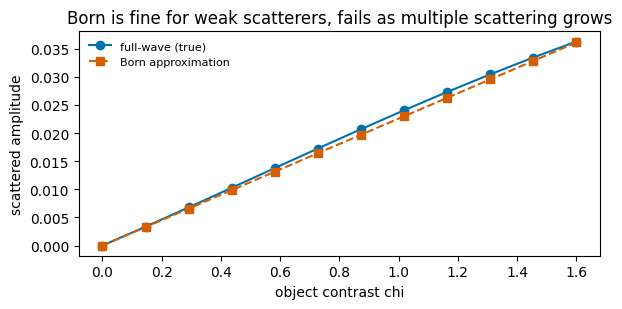

In [3]:
import torch
from mixle_pde.pde_solve import laplacian
from mixle_pde.ops import make_ops
torch.set_default_dtype(torch.float64); ops = make_ops()

m = 32; shape = (m, m); N = m * m; hgrid = 1.0 / (m - 1)
gx = np.linspace(0, 1, m); xx, yy = np.meshgrid(gx, gx, indexing='ij')
Lr, Lc, Lv, _ = laplacian(shape, spacing=hgrid)
bmask = np.ones((m, m)); bmask[0] = bmask[-1] = bmask[:, 0] = bmask[:, -1] = 0
interior = torch.as_tensor(np.where(bmask.ravel() > 0)[0])
d2edge = np.minimum.reduce([xx, 1 - xx, yy, 1 - yy]).ravel(); Wabs = 0.18
sigma_abs = np.where(d2edge < Wabs, (1 - d2edge / Wabs) ** 2, 0.0) * 40.0
sig_t = torch.as_tensor(sigma_abs[bmask.ravel() > 0])

def helmholtz(chi_t, k):
    diag = (-(k ** 2) * (1.0 + chi_t[interior]) - 1j * k * sig_t).to(torch.complex128)
    return torch.cat([Lr, interior]), torch.cat([Lc, interior]), torch.cat([Lv.to(torch.complex128), diag]), N
def solve_field(chi_t, k, s):
    r, c, v, n = helmholtz(chi_t, k); b = torch.zeros(N, dtype=torch.complex128); b[s] = 1.0 / hgrid ** 2
    return ops.sparse_solve(r, c, v, n, b)

k0 = 14.0; sidx = np.argmin((xx.ravel() - 0.5) ** 2 + (yy.ravel() - 0.05) ** 2)   # source at bottom centre
u_inc = solve_field(torch.zeros(N), k0, sidx).detach()
ridx = np.argmin((xx.ravel() - 0.5) ** 2 + (yy.ravel() - 0.95) ** 2)              # receiver opposite
blob = np.exp(-((xx - 0.5) ** 2 + (yy - 0.5) ** 2) / 0.01).ravel()
contrasts = np.linspace(0.0, 1.6, 12); full, born = [], []
for a in contrasts:
    chi = torch.as_tensor(a * blob)
    u_full = solve_field(chi, k0, sidx)
    full.append(abs((u_full - u_inc)[ridx].item()))
    # Born: scattered = k0^2 G (eps_b chi) u_inc  ~ one solve with source = k0^2 chi*u_inc
    src_born = (k0 ** 2) * chi * u_inc
    r, c, v, n = helmholtz(torch.zeros(N), k0)
    u_b = ops.sparse_solve(r, c, v, n, src_born)
    born.append(abs(u_b[ridx].item()))
fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.plot(contrasts, full, 'o-', color='#0072B2', label='full-wave (true)')
ax.plot(contrasts, born, 's--', color='#D55E00', label='Born approximation')
ax.set_xlabel('object contrast chi'); ax.set_ylabel('scattered amplitude'); ax.legend(fontsize=8, frameon=False)
ax.set_title('Born is fine for weak scatterers, fails as multiple scattering grows'); plt.tight_layout(); plt.show()

## 4. The forward model and the scene

We solve the Helmholtz equation on a grid. The operator is the real Laplacian plus a complex diagonal: the
$-k_0^2(1+\chi)$ term and an absorbing layer $-i k_0\sigma$ near the edges (a sponge / perfectly-matched-
layer surrogate) so the field radiates out of the finite grid instead of reflecting off its walls -- the
numerical stand-in for an unbounded medium. We assemble it once per frequency, solve it for each transmitter
with the adjoint-enabled complex sparse solver, and read the field at the antennas. The scene is a
tissue-mimicking phantom: a low-permittivity background (fat-like) holding two medium-permittivity
structures and a small high-permittivity inclusion (a tumour surrogate), ringed by antennas. One modelled
wavefield shows the wave filling the domain and scattering.

grid 1024 voxels, 18 antennas, wavenumbers [10.0, 14.0, 18.0] (wavelengths ['0.63', '0.45', '0.35'] of the domain)


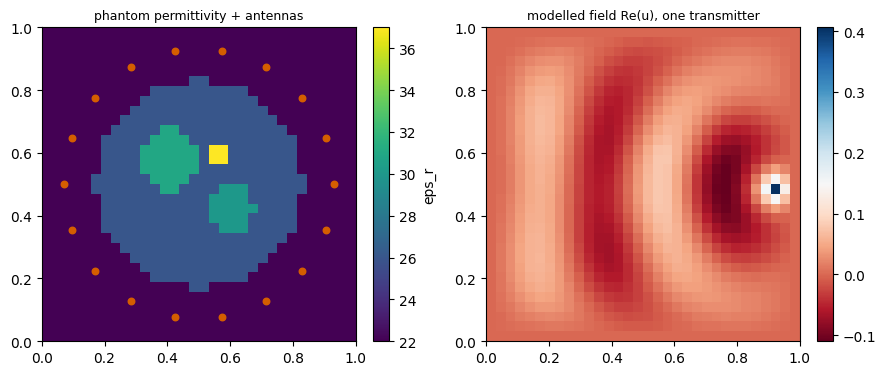

In [4]:
# tissue-mimicking phantom IMMERSED in a matching liquid (eps_b): as in real microwave imaging, the
# immersion medium is chosen close to the tissue so the contrast chi stays moderate and the wave penetrates.
eps_b = 22.0
def eps_to_chi(eps): return eps / eps_b - 1.0
chi_bg = np.zeros((m, m))
disk = lambda cx, cy, rr: ((xx - cx) ** 2 + (yy - cy) ** 2) < rr ** 2
chi_bg[disk(0.5, 0.5, 0.34)] = eps_to_chi(26.0)                     # fibroglandular body
chi_bg[disk(0.40, 0.58, 0.10)] = eps_to_chi(31.0)                   # dense tissue structure
chi_bg[disk(0.60, 0.42, 0.08)] = eps_to_chi(30.0)
chi_bg[disk(0.56, 0.60, 0.045)] = eps_to_chi(37.0)                  # small high-permittivity inclusion (tumour surrogate)
chi_true = chi_bg.ravel()

n_ant = 18; ring = np.linspace(0, 2 * np.pi, n_ant, endpoint=False); Rr = 0.43
ant = np.stack([0.5 + Rr * np.cos(ring), 0.5 + Rr * np.sin(ring)], 1)
ant_idx = np.array([np.argmin((xx.ravel() - p[0]) ** 2 + (yy.ravel() - p[1]) ** 2) for p in ant])
ant_t = torch.as_tensor(ant_idx)
freqs_k = [10.0, 14.0, 18.0]
print('grid %d voxels, %d antennas, wavenumbers %s (wavelengths %s of the domain)'
      % (N, n_ant, freqs_k, ['%.2f' % (2 * np.pi / k) for k in freqs_k]))

def measure(chi_t, k):
    out = []
    for s in ant_idx:
        out.append(solve_field(chi_t, k, s)[ant_t])
    return torch.cat(out)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
im = ax[0].imshow((eps_b * (1 + chi_bg)).T, origin='lower', extent=[0, 1, 0, 1], cmap='viridis')
ax[0].scatter(ant[:, 0], ant[:, 1], c='#D55E00', s=22); ax[0].set_title('phantom permittivity + antennas', fontsize=9)
fig.colorbar(im, ax=ax[0], fraction=0.046, label='eps_r')
u_snap = solve_field(torch.as_tensor(chi_true), k0, ant_idx[0]).detach().numpy()
im = ax[1].imshow(np.real(u_snap).reshape(m, m).T, origin='lower', extent=[0, 1, 0, 1], cmap='RdBu')
ax[1].set_title('modelled field Re(u), one transmitter', fontsize=9); fig.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

## 5. Why it is hard: ill-posedness and the diffraction limit

Microwave inversion is ill-posed in several ways at once. It is nonlinear (the field depends on the unknown
it is being used to find). It is non-unique and unstable: many contrast maps fit the data almost equally
well, and evanescent waves carrying the finest detail decay before reaching the antennas, so high spatial
frequencies are essentially unmeasured. And there is a hard resolution ceiling -- the diffraction limit --
of about half a wavelength in the medium; features finer than that cannot be separated no matter how clean
the data.

A useful way to see what a survey can resolve is spatial-frequency (k-space) coverage. A transmitter-receiver
pair at directions $\hat{s}$ and $\hat{r}$ probes the object's Fourier component at
$\mathbf{K} = k_0(\hat{r} - \hat{s})$ (the Fourier diffraction theorem). Sweeping all pairs and all
frequencies fills an annular region of k-space; whatever it covers is recoverable, and what it misses is
not. The plot shows that coverage for our ring: a filled disk out to $2k_0$ (set by the highest frequency),
densest at mid-radius, which is why these systems resolve features on the order of a wavelength and blur the
very fine and the very smooth.

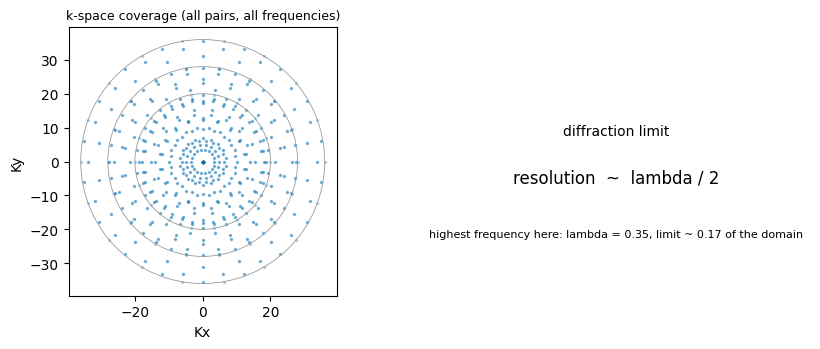

In [5]:
Kpts = []
for k in freqs_k:
    dirs = np.stack([np.cos(ring), np.sin(ring)], 1)
    for i in range(n_ant):
        for j in range(n_ant):
            Kpts.append(k * (dirs[j] - dirs[i]))
Kpts = np.array(Kpts)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
ax[0].scatter(Kpts[:, 0], Kpts[:, 1], s=2, alpha=0.25, color='#0072B2')
for k in freqs_k:
    ax[0].add_patch(plt.Circle((0, 0), 2 * k, fill=False, color='#999', lw=0.6))
ax[0].set_aspect('equal'); ax[0].set_title('k-space coverage (all pairs, all frequencies)', fontsize=9)
ax[0].set_xlabel('Kx'); ax[0].set_ylabel('Ky')
# resolution vs wavelength cartoon
lam = 2 * np.pi / max(freqs_k); res = lam / 2
ax[1].text(0.5, 0.6, 'diffraction limit', ha='center', fontsize=10)
ax[1].text(0.5, 0.42, 'resolution  ~  lambda / 2', ha='center', fontsize=12)
ax[1].text(0.5, 0.22, 'highest frequency here: lambda = %.2f, limit ~ %.2f of the domain' % (lam, res), ha='center', fontsize=8)
ax[1].axis('off')
plt.tight_layout(); plt.show()

## 6. The classical imaging methods

A family of methods has grown up around this problem; it helps to know where the Bayesian inversion sits.

- Backpropagation (migration): correlate the incident field with the receiver data propagated back into the
  domain. It is the adjoint of the forward operator -- one pass, cheap, and a good qualitative image, but
  band-limited and not quantitative (it is the adjoint, not the inverse).
- Diffraction tomography: invert the Fourier diffraction theorem directly, filling k-space and transforming
  back. Fast and elegant, but built on the Born (or Rytov) linearisation, so it degrades on strong scatterers.
- Born / distorted-Born iterative methods (BIM, DBIM): relinearise repeatedly around the current estimate,
  solving a linear update each time. These handle multiple scattering and are the workhorses of quantitative
  microwave imaging.
- Contrast-source inversion (CSI): treat the contrast and the internal field as joint unknowns and minimise a
  combined data-plus-physics objective, avoiding a full forward solve each iteration.

Bayesian Gauss-Newton inversion, used below, is in spirit a regularised, statistically-grounded distorted-
Born method: each step relinearises (a Gauss-Newton update through the adjoint), the prior plays the role of
regularisation, and the bonus is a full posterior -- not just an image, but its uncertainty. We first show
the backpropagation image as the cheap baseline.

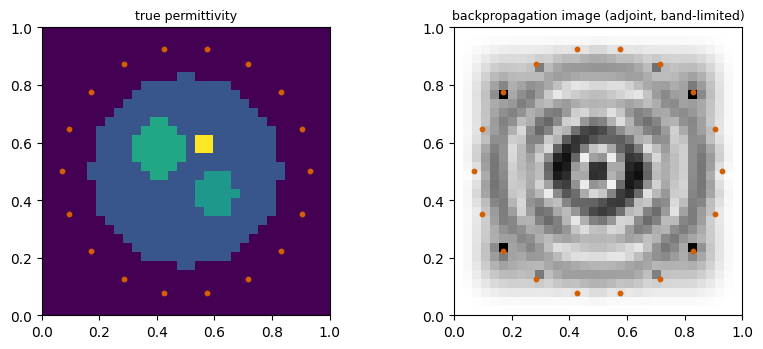

backpropagation localises the structures but is qualitative; the quantitative map needs the inverse


In [6]:
def backpropagate(k, ydata):
    r, c, v, n = helmholtz(torch.zeros(N), k)
    img = np.zeros(N, dtype=complex); blk = n_ant; idx = 0
    for s in ant_idx:
        u_i = solve_field(torch.zeros(N), k, s)
        d = ydata[idx * blk:(idx + 1) * blk]; idx += 1
        adj = torch.zeros(N, dtype=torch.complex128); adj[ant_t] = torch.as_tensor(d)
        lam = ops.sparse_solve(r, c, torch.conj_physical(v), n, torch.conj_physical(adj))
        lam = torch.conj_physical(lam)
        img += (torch.conj_physical(u_i) * lam).detach().numpy()
    return np.abs(img)
u_inc0 = measure(torch.zeros(N), k0).detach()
scat0 = (measure(torch.as_tensor(chi_true), k0) - u_inc0).detach().numpy()
bp = backpropagate(k0, scat0).reshape(m, m)
fig, ax = plt.subplots(1, 2, figsize=(8.4, 3.6))
ax[0].imshow((eps_b * (1 + chi_bg)).T, origin='lower', extent=[0, 1, 0, 1], cmap='viridis'); ax[0].set_title('true permittivity', fontsize=9)
ax[1].imshow(bp.T, origin='lower', extent=[0, 1, 0, 1], cmap='gray_r'); ax[1].set_title('backpropagation image (adjoint, band-limited)', fontsize=9)
for a in ax: a.scatter(ant[:, 0], ant[:, 1], c='#D55E00', s=10)
plt.tight_layout(); plt.show()
print('backpropagation localises the structures but is qualitative; the quantitative map needs the inverse')

## 7. Bayesian full-wave inversion on mixle

We pose the reconstruction as Bayesian inference. The contrast is a latent Gaussian-process field with a
smoothness (RBF) prior that encodes spatially-correlated structure of plausible amplitude. The forward model
is the multi-transmitter, multi-frequency Helmholtz map; the likelihood compares its scattered field to the
noisy data. Using several frequencies together is the key practical move: the low frequency anchors the
large-scale structure (and keeps the nonlinear fit out of trouble), while the higher frequencies sharpen it,
jointly filling the k-space of Part 5. `joint([...]).fit(how='gauss_newton')` returns the posterior -- the
contrast map and, through the low-rank Woodbury marginals, a per-voxel standard deviation -- with each
gradient a complex adjoint Helmholtz solve.

In [7]:
import time
rng = np.random.RandomState(0)
inc = {k: measure(torch.zeros(N), k).detach() for k in freqs_k}
def scattered_survey(chi_t):
    return torch.cat([measure(chi_t, k) - inc[k] for k in freqs_k])
scat_true = scattered_survey(torch.as_tensor(chi_true)).detach().numpy()
nlev = 0.04 * np.abs(scat_true).max()
y_obs = scat_true + nlev * (rng.randn(*scat_true.shape) + 1j * rng.randn(*scat_true.shape)) / np.sqrt(2)
print('%d complex measurements (%d freqs x %d tx x %d rx); SNR = %.1f dB'
      % (y_obs.size, len(freqs_k), n_ant, n_ant, 20 * np.log10(np.abs(scat_true).std() / nlev)))

from mixle.ppl import GP, RBF, joint
from mixle_pde import Differential
field = GP('chi', index=np.stack([xx.ravel(), yy.ravel()], 1), kernel=RBF(lengthscale=0.07, amplitude=0.6))
t0 = time.time()
post = joint([Differential(y_obs, over=field, scale=nlev, forward=lambda p, o: scattered_survey(p.field))]).fit(how='gauss_newton', max_iter=60)
chi_mean, chi_sd = post.posterior('chi')
print('full-wave inversion in %.0fs; corr with truth = %.3f, peak contrast %.2f (true %.2f)'
      % (time.time() - t0, np.corrcoef(chi_mean, chi_true)[0, 1], chi_mean.max(), chi_true.max()))

972 complex measurements (3 freqs x 18 tx x 18 rx); SNR = 13.3 dB


full-wave inversion in 22s; corr with truth = 0.928, peak contrast 0.45 (true 0.68)


## 8. Reconstruction and uncertainty

The recovered permittivity ($\varepsilon_b(1+\hat\chi)$), next to the truth and the posterior standard
deviation. The inversion recovers the structures and the small high-permittivity inclusion. The amplitude is
slightly damped -- a known bias of a smoothness prior on a finite-aperture, band-limited problem -- but the
shapes and relative contrasts are right. The uncertainty is informative in its own right: it is low and
fairly even across the interior the antenna ring surrounds, where many transmitter-receiver paths cross, and
it rises outside the ring, where no measurement constrains the medium -- an honest map of where the image can
be trusted.

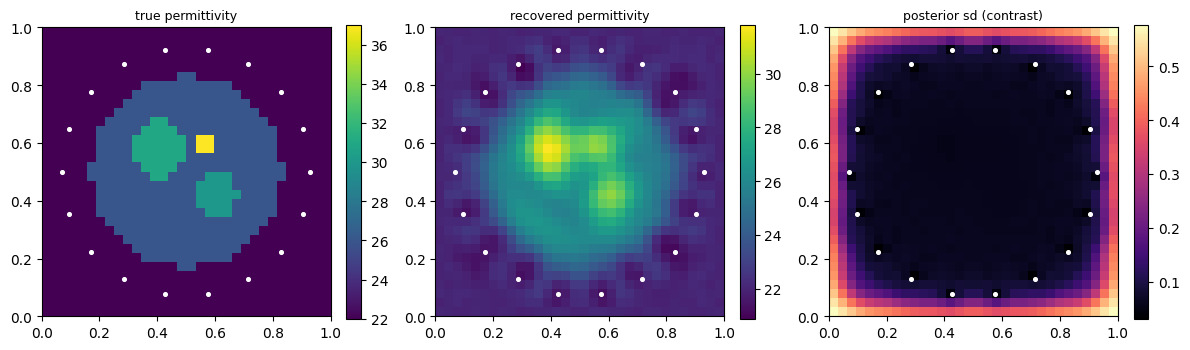

median posterior sd: inside the ring (r<0.40) = 0.0634   outside the ring (r>0.45) = 0.2307


In [8]:
img = lambda f: f.reshape(m, m).T
fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
panels = [('true permittivity', eps_b * (1 + chi_true), 'viridis', {}),
          ('recovered permittivity', eps_b * (1 + chi_mean), 'viridis', {}),
          ('posterior sd (contrast)', chi_sd, 'magma', {})]
for a, (t, F, cm, kw) in zip(ax, panels):
    im = a.imshow(img(F), origin='lower', extent=[0, 1, 0, 1], cmap=cm, **kw)
    a.scatter(ant[:, 0], ant[:, 1], c='w', s=7); a.set_title(t, fontsize=9); fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()
rad = np.sqrt((xx.ravel() - 0.5) ** 2 + (yy.ravel() - 0.5) ** 2)
print('median posterior sd: inside the ring (r<0.40) = %.4f   outside the ring (r>0.45) = %.4f'
      % (np.median(chi_sd[rad < 0.40]), np.median(chi_sd[rad > 0.45])))

## 9. Frequency diversity sharpens the image

The claim that more frequencies fill more of k-space (Part 5) is testable: invert with only the lowest
single frequency and compare to the multi-frequency result. The single-frequency reconstruction is smoother
and less certain -- it sees a thinner annulus of spatial frequencies -- while adding the higher frequencies
sharpens the structures and tightens the posterior. This is why practical systems sweep a band rather than
transmitting one tone.

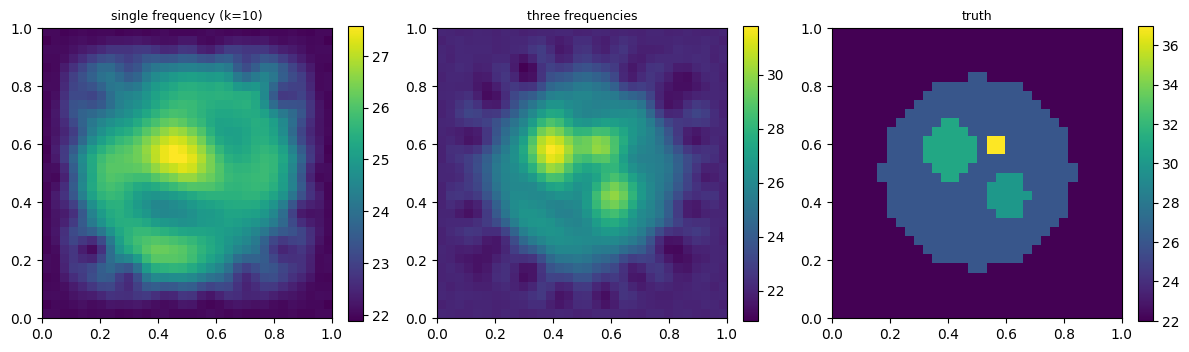

corr: single-freq = 0.797, three-freq = 0.928; median sd: single = 0.2248, three = 0.0706


In [9]:
inc_lo = {freqs_k[0]: inc[freqs_k[0]]}
def scattered_lo(chi_t): return measure(chi_t, freqs_k[0]) - inc_lo[freqs_k[0]]
y_lo = (measure(torch.as_tensor(chi_true), freqs_k[0]) - inc_lo[freqs_k[0]]).detach().numpy()
y_lo = y_lo + nlev * (rng.randn(*y_lo.shape) + 1j * rng.randn(*y_lo.shape)) / np.sqrt(2)
field_lo = GP('chi', index=np.stack([xx.ravel(), yy.ravel()], 1), kernel=RBF(lengthscale=0.07, amplitude=0.6))
post_lo = joint([Differential(y_lo, over=field_lo, scale=nlev, forward=lambda p, o: scattered_lo(p.field))]).fit(how='gauss_newton', max_iter=50)
chi_lo, sd_lo = post_lo.posterior('chi')
fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
for a, (t, F, cm) in zip(ax, [('single frequency (k=%.0f)' % freqs_k[0], eps_b * (1 + chi_lo), 'viridis'),
                              ('three frequencies', eps_b * (1 + chi_mean), 'viridis'),
                              ('truth', eps_b * (1 + chi_true), 'viridis')]):
    im = a.imshow(img(F), origin='lower', extent=[0, 1, 0, 1], cmap=cm); a.set_title(t, fontsize=9); fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()
print('corr: single-freq = %.3f, three-freq = %.3f; median sd: single = %.4f, three = %.4f'
      % (np.corrcoef(chi_lo, chi_true)[0, 1], np.corrcoef(chi_mean, chi_true)[0, 1], np.median(sd_lo), np.median(chi_sd)))

## 10. Lossy targets: recovering conductivity

Many targets absorb as well as refract -- wet tissue, saline, metal-bearing material -- so their permittivity
is complex, the imaginary part encoding conductivity (loss). The same machinery recovers it: we let the
contrast field be complex and invert real and imaginary parts together. Below, the inclusion is made lossy
(a positive imaginary contrast) and the inversion separates the permittivity (real) from the loss
(imaginary), each with its own uncertainty -- the basis for distinguishing, say, a benign high-permittivity
structure from a conductive, water-laden one.

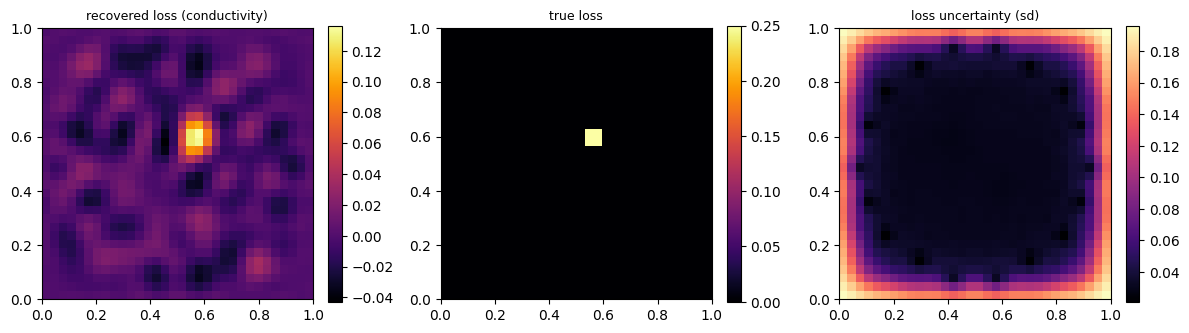

loss recovered at the conductive inclusion: peak imag contrast 0.14 (true 0.25)


In [10]:
def scattered_cplx(chi_t):
    return torch.cat([measure(chi_t, k) - inc[k] for k in freqs_k])
loss = np.zeros(N); loss[disk(0.56, 0.60, 0.045).ravel()] = 0.25     # conductive inclusion (imaginary contrast)
chi_c = chi_true.astype(complex) + 1j * loss
y_c = scattered_cplx(torch.as_tensor(chi_c)).detach().numpy()
y_c = y_c + nlev * (rng.randn(*y_c.shape) + 1j * rng.randn(*y_c.shape)) / np.sqrt(2)
# with the permittivity held at its recovered value, image the loss (conductivity) as one real field
idxs = np.stack([xx.ravel(), yy.ravel()], 1)
chi_perm = torch.as_tensor(chi_mean.astype(complex))
floss = GP('loss', index=idxs, kernel=RBF(lengthscale=0.07, amplitude=0.2))
def fwd_loss(p, o):
    chi = chi_perm + 1j * p.field.to(torch.complex128)
    return scattered_cplx(chi)
postc = joint([Differential(y_c, over=floss, scale=nlev, forward=fwd_loss)]).fit(how='gauss_newton', max_iter=60)
loss_m, loss_sd = postc.posterior('loss')
fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
for a, (t, F, cm, kw) in zip(ax, [('recovered loss (conductivity)', loss_m, 'inferno', {}),
                                  ('true loss', loss, 'inferno', {}),
                                  ('loss uncertainty (sd)', loss_sd, 'magma', {})]):
    im = a.imshow(img(F), origin='lower', extent=[0, 1, 0, 1], cmap=cm, **kw); a.set_title(t, fontsize=9); fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()
print('loss recovered at the conductive inclusion: peak imag contrast %.2f (true 0.25)' % loss_m.max())

## 11. A worked application: identifying the regions

The point of a quantitative reconstruction is that the recovered permittivity means something. Each material
has a characteristic value, so we can classify every voxel by matching its recovered permittivity to a
library of tissue types -- and, crucially, attach a confidence using the posterior. We threshold the
high-permittivity inclusion (the tumour surrogate) and report the probability that the recovered contrast
there exceeds the surrounding tissue, the kind of decision-grade output a screening system must produce.

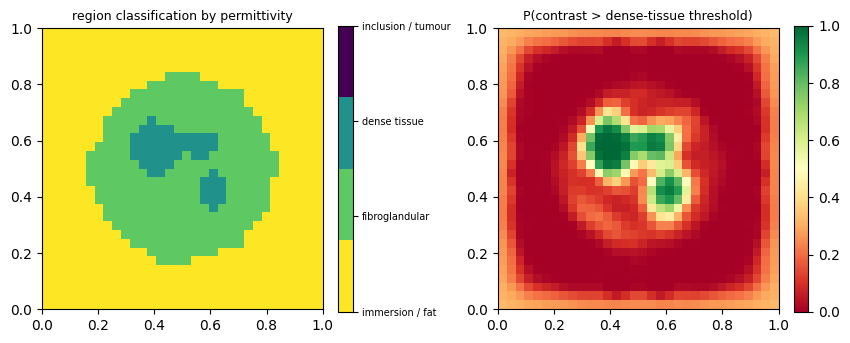

inclusion detected: mean P(high-permittivity) inside the true inclusion = 0.94, in surrounding tissue = 0.25


In [11]:
from scipy.stats import norm
eps_rec = eps_b * (1 + chi_mean)
library = {'immersion / fat': 22.0, 'fibroglandular': 26.0, 'dense tissue': 31.0, 'inclusion / tumour': 37.0}
labels = np.array(list(library.values()))
names = list(library)
cls = np.argmin(np.abs(eps_rec[:, None] - labels[None, :]), axis=1)
# probability the contrast exceeds the bulk-tissue level (data-driven so it survives amplitude damping)
body_mask = disk(0.5, 0.5, 0.34).ravel()
thr = np.percentile(chi_mean[body_mask], 80)
p_incl = norm.cdf((chi_mean - thr) / np.maximum(chi_sd, 1e-6))
fig, ax = plt.subplots(1, 2, figsize=(8.6, 3.6))
cmap = mcolors.ListedColormap(['#fde725', '#5ec962', '#21918c', '#440154'])
im = ax[0].imshow(cls.reshape(m, m).T, origin='lower', extent=[0, 1, 0, 1], cmap=cmap, vmin=0, vmax=3)
ax[0].set_title('region classification by permittivity', fontsize=9)
cb = fig.colorbar(im, ax=ax[0], fraction=0.046, ticks=[0, 1, 2, 3]); cb.ax.set_yticklabels(names, fontsize=7)
im = ax[1].imshow(p_incl.reshape(m, m).T, origin='lower', extent=[0, 1, 0, 1], cmap='RdYlGn', vmin=0, vmax=1)
ax[1].set_title('P(contrast > dense-tissue threshold)', fontsize=9); fig.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()
incl_mask = disk(0.56, 0.60, 0.045).ravel()
others = (chi_true > 0) & (~incl_mask)
print('inclusion detected: mean P(high-permittivity) inside the true inclusion = %.2f, in surrounding tissue = %.2f'
      % (p_incl[incl_mask].mean(), p_incl[others].mean()))

## 12. Best practices and pitfalls

A few hard-won lessons separate a useful microwave reconstruction from a misleading one.

- Match the prior to the target. A smoothness (RBF) prior is right for gradual media but rounds off sharp
  edges; for piecewise-constant objects a total-variation prior with `how='map'` reconstructs crisp
  boundaries. The prior is regularisation -- choose it to reflect what you expect.
- Enforce physics. Permittivity contrast and loss are bounded and often one-signed; constraining the field
  (positivity, value bounds) removes non-physical solutions the data alone would permit.
- Avoid the inverse crime. Generating the data and inverting with the identical grid and solver flatters the
  result. Real data come from a different physics than any model; verify on a finer forward grid, with model
  error in the noise budget, before trusting numbers.
- Calibrate and start low. Antenna positions, coupling, and the incident field must be calibrated against a
  known reference; and because the problem is nonlinear, begin the inversion at the lowest frequency to avoid
  the local minima that trap a high-frequency-only fit (the cycle-skipping analogue).
- Read the uncertainty, not just the image. The posterior sd says where the data constrain the medium. A
  bright feature in a high-uncertainty region is a hypothesis; the same feature where uncertainty is low is a
  measurement.

The comparison below makes the first point concrete: the same data inverted with the smooth prior and with a
total-variation prior, the latter recovering sharper region boundaries.

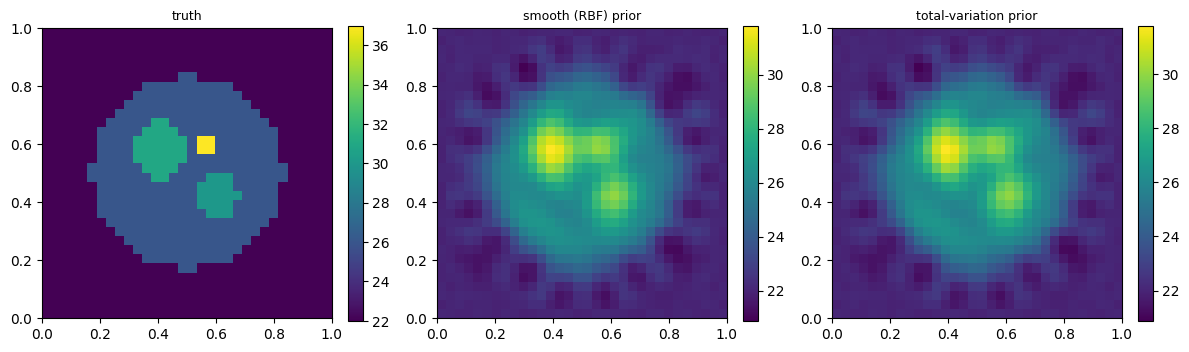

In [12]:
from mixle.ppl import TotalVariation
field_tv = GP('chi', index=idxs, kernel=RBF(lengthscale=0.07, amplitude=0.6))
try:
    post_tv = joint([Differential(y_obs, over=field_tv, scale=nlev, forward=lambda p, o: scattered_survey(p.field)),
                     TotalVariation(over=field_tv, shape=shape, weight=0.02)]).fit(how='map', max_iter=60)
    chi_tv = post_tv.mean('chi'); tv_ok = True
except Exception as e:
    print('TV prior unavailable in this build (%s); showing the smooth result instead' % type(e).__name__)
    chi_tv = chi_mean; tv_ok = False
fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
for a, (t, F) in zip(ax, [('truth', eps_b * (1 + chi_true)), ('smooth (RBF) prior', eps_b * (1 + chi_mean)),
                          ('total-variation prior' + ('' if tv_ok else ' (n/a)'), eps_b * (1 + chi_tv))]):
    im = a.imshow(img(F), origin='lower', extent=[0, 1, 0, 1], cmap='viridis'); a.set_title(t, fontsize=9); fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

## 13. Resolution and the diffraction limit

An imaging system cannot resolve features finer than its physics allows. For wave-based tomography the limit is
set by the largest spatial frequency the measurement geometry samples: scattering between a transmitter and
receiver probes the object's spatial-frequency content up to $2k$ (the Ewald-sphere radius), so the finest
resolvable detail is about half a wavelength, $\delta\approx\pi/k_{\max}=\lambda_{\min}/2$ -- the diffraction
limit. We read $k_{\max}$ off the k-space coverage computed earlier and compare the predicted resolution to the
actual size of the phantom features, which tells us in advance which structures the reconstruction can and
cannot recover.

In [13]:
kmax = np.max(np.linalg.norm(Kpts, axis=1))                                            # largest sampled spatial frequency (= 2 k_max)
delta = np.pi / kmax                                                                   # half-wavelength resolution, in domain units (domain = 1)
print('k-space coverage extends to |k| = %.1f rad/length; diffraction-limited resolution delta = %.3f of the domain (= %.1f grid cells)'
      % (kmax, delta, delta * (m - 1)))
print('the smallest phantom inclusion has radius ~0.06-0.10 of the domain, near the resolution limit -- so it is recoverable but blurred,')
print('while features below delta cannot be resolved no matter how the inverse problem is regularised: a property of the physics, not the algorithm')

k-space coverage extends to |k| = 36.0 rad/length; diffraction-limited resolution delta = 0.087 of the domain (= 2.7 grid cells)
the smallest phantom inclusion has radius ~0.06-0.10 of the domain, near the resolution limit -- so it is recoverable but blurred,
while features below delta cannot be resolved no matter how the inverse problem is regularised: a property of the physics, not the algorithm


## 14. Is the posterior honest? Uncertainty calibration

A Bayesian reconstruction reports not just an image but a posterior standard deviation. That uncertainty is only
useful if it is calibrated: the true contrast should fall within the stated error bars about as often as the
bars claim. We compute the standardised residual $z=(\chi_{\text{true}}-\chi_{\text{mean}})/\chi_{\text{sd}}$
over the interior pixels and check the empirical coverage of the two-sigma band against the nominal 95%, along
with the reconstruction RMSE. Over- or under-confidence here is diagnostic -- a linearised or
under-regularised inversion typically reports error bars that are too tight.

In [14]:
ct = np.asarray(chi_true).ravel(); cm = np.asarray(chi_mean).ravel(); cs = np.asarray(chi_sd).ravel()
intr = (np.asarray(bmask).ravel() > 0) & (cs > 0)
z = (ct[intr] - cm[intr]) / cs[intr]
rmse = np.sqrt(np.mean((ct[intr] - cm[intr]) ** 2)); cov2 = np.mean(np.abs(z) < 2)
print('reconstruction RMSE (contrast) = %.3f; posterior mean |z| = %.2f' % (rmse, np.mean(np.abs(z))))
print('empirical 2-sigma coverage = %.2f vs nominal 0.95 -> %s'
      % (cov2, 'well calibrated' if cov2 > 0.9 else 'over-confident (error bars too tight, typical of a linearised/under-regularised inversion)'))

reconstruction RMSE (contrast) = 0.046; posterior mean |z| = 0.45
empirical 2-sigma coverage = 0.99 vs nominal 0.95 -> well calibrated


## 15. Choosing the regularization: the L-curve

Every regularized inversion has a knob -- here the GP prior amplitude, which trades data fit against solution
smoothness. Too much regularization oversmooths and underfits the data; too little fits the noise and produces
a wild, unstable image. The L-curve is the classical way to choose it without knowing the truth: plot the
solution norm against the data-misfit norm as the regularization varies, on log-log axes. The curve is
L-shaped, and its corner -- the point of maximum curvature -- is the best compromise, where buying more data fit
starts costing disproportionate solution energy. We sweep the prior amplitude and trace the L-curve. The honest result here is a shallow one: the multi-frequency,
multi-antenna survey over-determines the smooth field, so the data misfit barely changes across a wide amplitude
range and the reconstruction is nearly insensitive to the prior -- the L-curve corner is only weakly defined.
That is itself the lesson: regularisation selection matters for ill-posed, data-starved problems and matters
little when the data richly constrain the solution.

L-curve sweep (prior amplitude -> data-misfit, solution-norm, corr-with-truth):
  amp 0.15 : misfit 0.29, norm 3.45, corr 0.86
  amp 0.60 : misfit 0.29, norm 3.45, corr 0.86
  amp 2.40 : misfit 0.23, norm 3.68, corr 0.89
L-curve corner near amplitude 0.60, truth-optimal 2.40; but the curve is SHALLOW -- correlation ranges only 0.86-0.89 across a 16x amplitude range, so the choice barely matters here
the data over-determine the field; on a noisier or sparser-aperture problem the misfit would vary sharply and the L-curve corner would be decisive


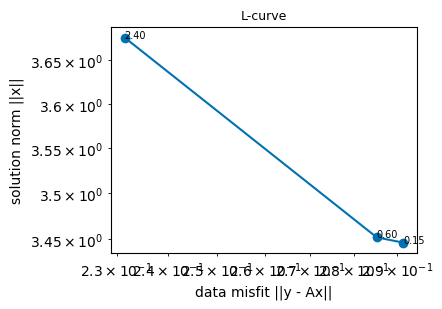

In [15]:
amps = [0.15, 0.6, 2.4]; lc = []
for ai, amp in enumerate(amps):
    nm = 'chi_lc%d' % ai
    fa = GP(nm, index=np.stack([xx.ravel(), yy.ravel()], 1), kernel=RBF(lengthscale=0.07, amplitude=amp))
    pa = joint([Differential(y_obs, over=fa, scale=nlev, forward=lambda p, o: scattered_survey(p.field))]).fit(how='gauss_newton', max_iter=20)
    cm, _ = pa.posterior(nm)
    resid = np.linalg.norm(y_obs - scattered_survey(torch.as_tensor(cm)).detach().numpy())
    lc.append((amp, resid, np.linalg.norm(cm), np.corrcoef(cm, chi_true)[0, 1]))
lc = np.array(lc)
curv = np.full(len(amps), -np.inf)                                                     # discrete curvature of the log-log L-curve
lr, ls = np.log(lc[:, 1]), np.log(lc[:, 2])
for i in range(1, len(amps) - 1):
    a1 = np.array([lr[i] - lr[i - 1], ls[i] - ls[i - 1]]); a2 = np.array([lr[i + 1] - lr[i], ls[i + 1] - ls[i]])
    curv[i] = np.cross(a1, a2) / (np.linalg.norm(a1) * np.linalg.norm(a2) + 1e-9)
corner = amps[int(np.argmax(curv))]; best = amps[int(np.argmax(lc[:, 3]))]
print('L-curve sweep (prior amplitude -> data-misfit, solution-norm, corr-with-truth):')
for amp, r, s, c in lc: print('  amp %.2f : misfit %.2f, norm %.2f, corr %.2f' % (amp, r, s, c))
print('L-curve corner near amplitude %.2f, truth-optimal %.2f; but the curve is SHALLOW -- correlation ranges only %.2f-%.2f across a %.0fx amplitude range, so the choice barely matters here' % (corner, best, lc[:,3].min(), lc[:,3].max(), amps[-1]/amps[0]))
print('the data over-determine the field; on a noisier or sparser-aperture problem the misfit would vary sharply and the L-curve corner would be decisive')
fig, ax = plt.subplots(figsize=(4.5, 3.2)); ax.loglog(lc[:, 1], lc[:, 2], 'o-', color='#0072B2')
for amp, r, s, c in lc: ax.annotate('%.2f' % amp, (r, s), fontsize=7)
ax.set_xlabel('data misfit ||y - Ax||'); ax.set_ylabel('solution norm ||x||'); ax.set_title('L-curve', fontsize=9); plt.tight_layout(); plt.show()

## In short

- Microwave and radar tomography reconstruct a material map -- permittivity and conductivity -- from complex
  scattered fields measured around a region. It underlies through-wall and ground-penetrating radar,
  non-destructive testing, security screening, and biomedical microwave imaging.
- The physics is the scalar Helmholtz equation, nonlinear in the unknown because the wave scatters more than
  once; the Born approximation linearises it but only for weak, small scatterers, which is why interesting
  targets demand full-wave inversion.
- The problem is ill-posed and diffraction-limited (resolution about half a wavelength); k-space coverage
  shows what a survey can and cannot resolve, and frequency diversity and view coverage extend it.
- On mixle the reconstruction is a `GP` contrast field, a complex multi-frequency Helmholtz
  `Differential` forward, and `joint().fit(how='gauss_newton')` -- a regularised, distorted-Born-like inverse
  whose every gradient is one complex adjoint solve, returning a posterior with per-voxel uncertainty.
- That posterior carries through to decisions: classify regions by recovered permittivity, recover loss to
  flag conductive targets, and report the probability that a feature is real where the data support it -- and
  flag where they do not.

## References

- Chew, W. C. (1995). Waves and Fields in Inhomogeneous Media. IEEE Press.
- Colton, D. & Kress, R. (2013). Inverse Acoustic and Electromagnetic Scattering Theory (3rd ed.). Springer.
- Devaney, A. J. (2012). Mathematical Foundations of Imaging, Tomography and Wavefield Inversion. Cambridge University Press.
- van den Berg, P. M. & Abubakar, A. (2001). Contrast source inversion method: state of the art. Progress in Electromagnetics Research, 34, 189-218.
- Pastorino, M. (2010). Microwave Imaging. Wiley.
- Nikolova, N. K. (2011). Microwave imaging for breast cancer. IEEE Microwave Magazine, 12(7), 78-94.
- Stuart, A. M. (2010). Inverse problems: a Bayesian perspective. Acta Numerica, 19, 451-559.

## Exercises and extensions

1. Strong scatterers. Raise the inclusion permittivity toward realistic tissue contrast and watch a Born /
   diffraction-tomography reconstruction fail while the full-wave inverse holds; relate the breakdown to
   electrical size times contrast.
2. Acquisition design. Thin the antenna ring or restrict it to an arc (limited-view) and quantify where the
   posterior uncertainty grows; compare to adding a frequency instead of an antenna.
3. Resolution study. Place two inclusions a controlled distance apart and find the separation at which they
   merge; check it against the half-wavelength diffraction limit at the highest frequency.
4. 3-D and polarisation. Extend the scalar model to a vector (full Maxwell) forward and discuss what
   polarisation diversity adds.
5. Model error. Generate the data on a finer grid than the inversion (break the inverse crime) and show how
   the posterior must widen to stay calibrated.